In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/clean_superstore.csv")
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [3]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')

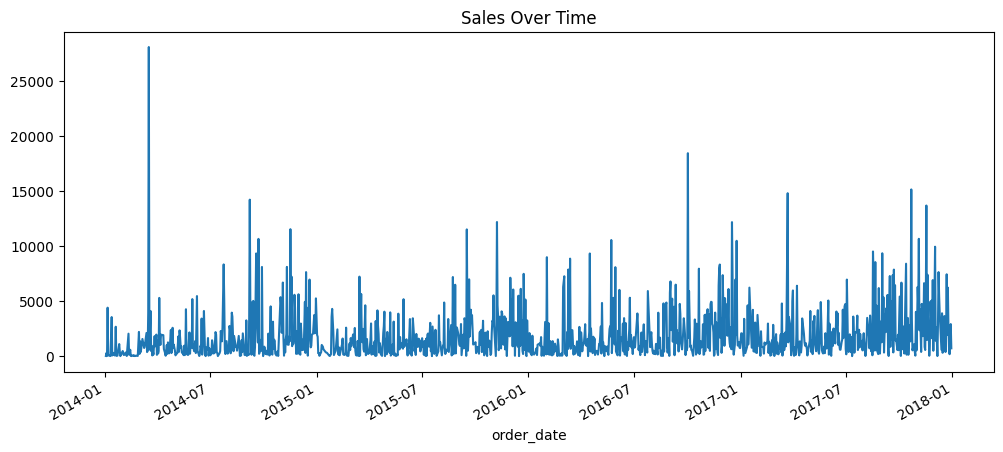

In [4]:
sales_over_time = df.groupby('order_date')['sales'].sum()

sales_over_time.plot(figsize=(12,5))
plt.title("Sales Over Time")
plt.show()

## Insight: Sales Trends

Sales show fluctuations over time, indicating possible seasonality.
Certain periods demonstrate spikes in sales, which may align with promotions or peak retail periods.

C:\Users\Cahil\AppData\Local\Temp\ipykernel_40564\2344068508.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key='order_date', freq='M'))['sales'].sum()


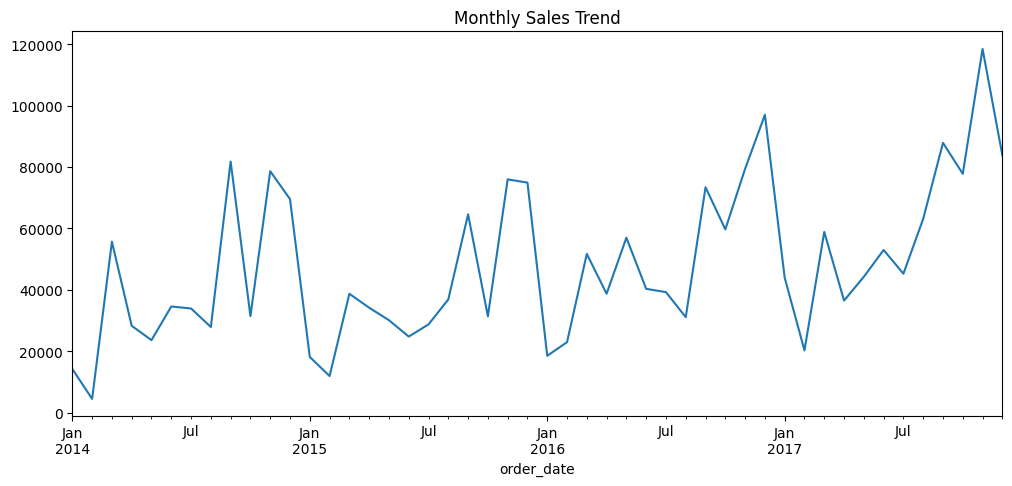

In [9]:
monthly_sales = df.groupby(pd.Grouper(key='order_date', freq='M'))['sales'].sum()

monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.show()

### Insight: Monthly Patterns

Monthly aggregation highlights recurring peaks, suggesting seasonal buying behaviour.

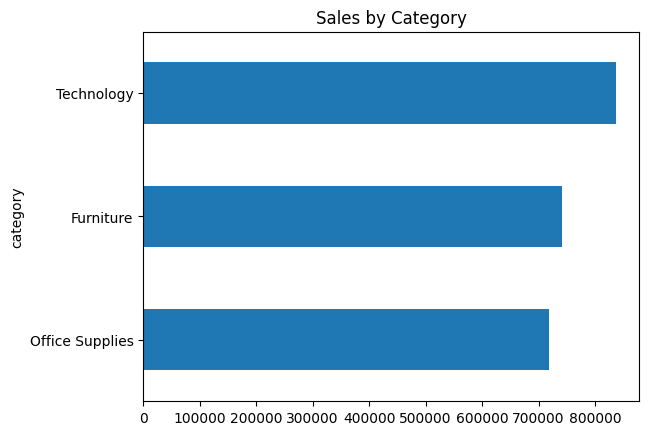

In [10]:
category_sales = df.groupby('category')['sales'].sum().sort_values()

category_sales.plot(kind='barh')
plt.title("Sales by Category")
plt.show()

### Insight: Category Performance

Technology dominates total sales, indicating key revenue driver. However the gap is not massively significant.

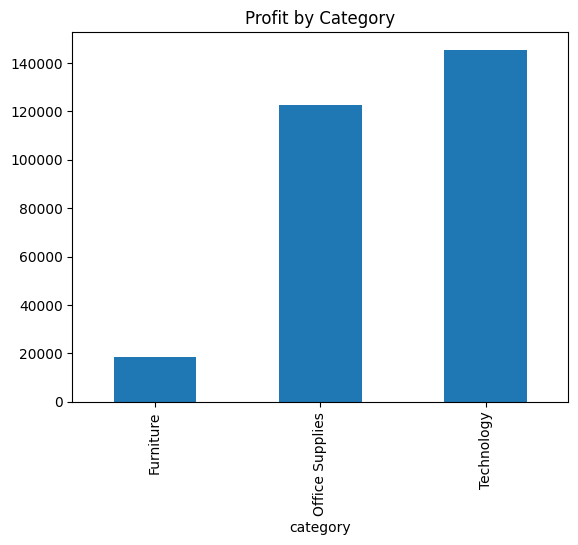

In [11]:
category_profit = df.groupby('category')['profit'].sum().sort_values()

category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.show()

### Insight: profitability Differences

High sales do not always translate to high profit.
Some categories may generate revenue but contribute less to profitability.

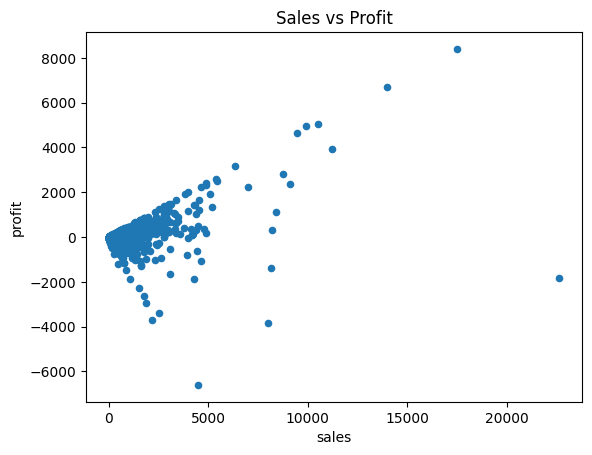

In [12]:
df.plot.scatter(x='sales', y='profit')
plt.title('Sales vs Profit')
plt.show()

### Insight: Sales vs Profit

While higher sales often correlate with higher profit, there are cases where higher sales result in low or negative profit.

This indicates potential issues such as heavy discounting or high costs.

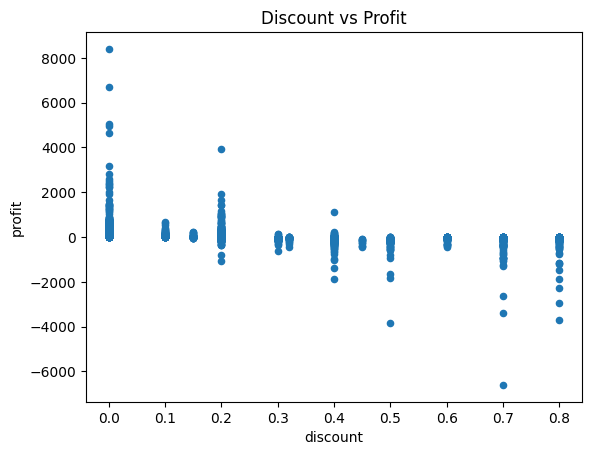

In [13]:
df.plot.scatter(x='discount', y='profit')
plt.title("Discount vs Profit")
plt.show()

### Insight: Discount Impact

Higher discounts are associated with lower or negative profit.

This suggests that aggressive discounting strategies may be harming profitability.

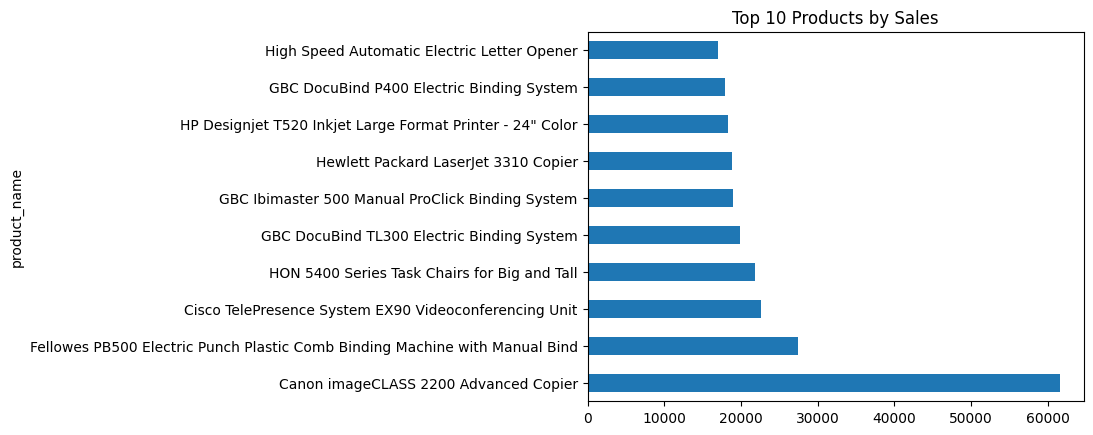

In [14]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending = False).head(10)

top_products.plot(kind='barh')
plt.title("Top 10 Products by Sales")
plt.show()

### Insight: Top Products

A small number of products contribute significantly to total sales, indicating a concentration of revenue sources.

In [18]:
bottom_products = df.groupby("product_name")['sales'].sum().sort_values().head(10)
bottom_products

product_name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Newell 308                                                          8.400
Name: sales, dtype: float64

### Insight: Underperforming Products

Certain products generate minimal sales and may be candidates for review or discontinuation.

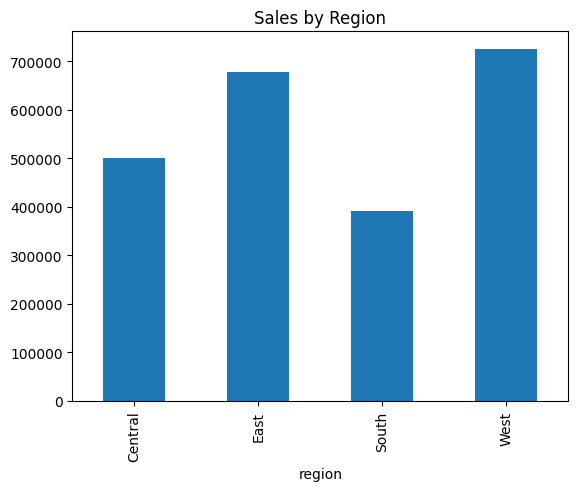

In [20]:
region_sales = df.groupby("region")['sales'].sum()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

### Insight: Regional Performance

Sales across regions, highlighting geographic differences in demand.

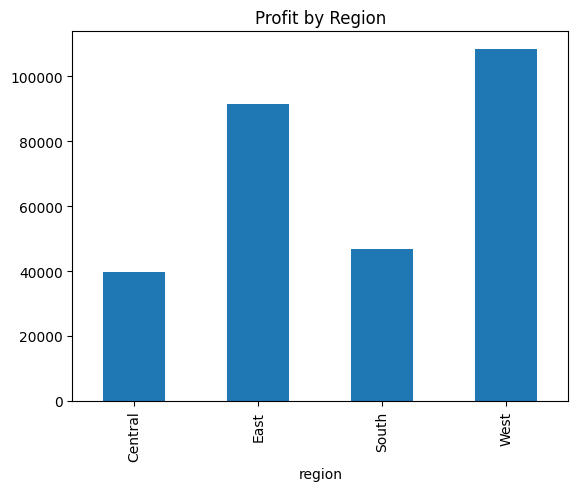

In [22]:
region_profit = df.groupby('region')['profit'].sum()

region_profit.plot(kind='bar')
plt.title("Profit by Region")
plt.show()

### Insight: Regional Profitability

Some regions may generate strong sales but lower profi, indicating inneficiencies or cost differences.

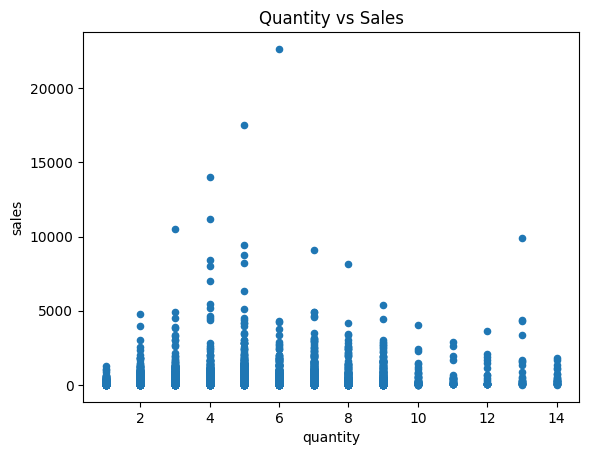

In [23]:
df.plot.scatter(x="quantity",y='sales')
plt.title("Quantity vs Sales")
plt.show()

### Insight: Order Size Impact

Higher quantities generally lead to higher sales, but variability suggests pricing and product differences.

## Key Business Insights

- Sales show seasonal patterns over time
- Certain categories dominate revenue
- High sales do not always equate to high profits
- Discounts negatively impact profitability
- Revenue is concentrated among top-performing products
- Regional differences highlight varying market performance

These insights will guide the design of the sales dashboard.